<a href="https://colab.research.google.com/github/Ahmad-Mustafa-Iqbal/UK-Online-Store-retail-eda/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['axes.unicode_minus'] = False

## 2. Load Dataset

In [ ]:
# Edit path for the dataset before running (Colab default shown below)
file_path = "/content/online_retail_II.xlsx"

sheet_2009_2010 = pd.read_excel(file_path, sheet_name="Year 2009-2010")
sheet_2010_2011 = pd.read_excel(file_path, sheet_name="Year 2010-2011")

df = pd.concat([sheet_2009_2010, sheet_2010_2011], ignore_index=True)

print(" Dataset Shape ")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print(" Columns ")
print(df.columns.tolist(), "\n")

print(" Data Types ")
print(df.dtypes, "\n")

print(" Date Range ")
print(f"{df['InvoiceDate'].min()}  to  {df['InvoiceDate'].max()}\n")

df.head()

 Dataset Shape Rows: 1067371, Columns: 8 Columns ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']  Data Types Invoice                objectStockCode              objectDescription            objectQuantity                int64InvoiceDate    datetime64[us]Price                 float64Customer ID           float64Country                   strdtype: object  Date Range 2009-12-01 07:45:00  to  2011-12-09 12:50:00

## 3. Missing Values & Duplicate Rows

In [ ]:
print(" Missing Values ")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_report[missing_report['Missing Count'] > 0], "\n")

print(" Duplicate Rows ")
print(f"Total Duplicate Rows: {df.duplicated().sum()}\n")

print(" Other Data Quality Observations ")
print(f"Rows with negative Quantity (returns/cancellations): {(df['Quantity'] < 0).sum()}")
print(f"Rows with zero Price: {(df['Price'] == 0).sum()}")
print(f"Rows with negative Price: {(df['Price'] < 0).sum()}")

 Missing Values              Missing Count  Missing %Description           4382       0.41Customer ID         243007      22.77  Duplicate Rows Total Duplicate Rows: 34335 Other Data Quality Observations Rows with negative Quantity (returns/cancellations): 22950Rows with zero Price: 6202Rows with negative Price: 5

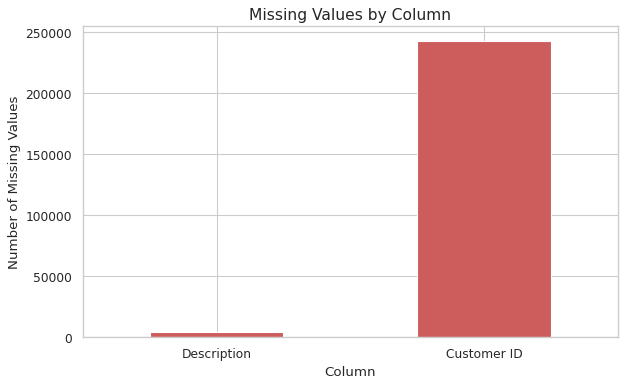

In [ ]:
# Visualize missing values
plt.figure(figsize=(8, 5))
missing_report[missing_report['Missing Count'] > 0]['Missing Count'].plot(
    kind='bar', color='indianred'
)
plt.title('Missing Values by Column', fontsize=14)
plt.xlabel('Column', fontsize=12)
plt.ylabel('Number of Missing Values', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** `Customer ID` and `Description` are the only columns with missing values. Rows with negative `Quantity` mostly represent cancelled orders (Invoice numbers starting with 'C'), and are kept in the dataset as instructed, but should be treated separately in any future revenue/recommendation modelling.

## 4. Top 10 Best-Selling Products

In [ ]:
# Create a Revenue column
df['Revenue'] = df['Quantity'] * df['Price']

top_quantity = df.groupby('Description')['Quantity'].sum().nlargest(10)
print(" Top 10 Products by Quantity Sold ")
print(top_quantity, "\n")

top_revenue = df.groupby('Description')['Revenue'].sum().nlargest(10)
print(" Top 10 Products by Revenue ")
print(top_revenue)

 Top 10 Products by Quantity Sold DescriptionWORLD WAR 2 GLIDERS ASSTD DESIGNS     108545WHITE HANGING HEART T-LIGHT HOLDER     93050ASSORTED COLOUR BIRD ORNAMENT          81306JUMBO BAG RED RETROSPOT                78090BROCADE RING PURSE                     70700PACK OF 60 PINK PAISLEY CAKE CASES     5657560 TEATIME FAIRY CAKE CASES            54366SMALL POPCORN HOLDER                   49616PACK OF 72 RETROSPOT CAKE CASES        49344PACK OF 72 RETRO SPOT CAKE CASES       46106Name: Quantity, dtype: int64  Top 10 Products by Revenue DescriptionREGENCY CAKESTAND 3 TIER               327813.65DOTCOM POSTAGE                         322647.47WHITE HANGING HEART T-LIGHT HOLDER     257533.90JUMBO BAG RED RETROSPOT                148800.64PARTY BUNTING                          147948.50ASSORTED COLOUR BIRD ORNAMENT          131413.85PAPER CHAIN KIT 50'S CHRISTMAS         121662.14POSTAGE                                112341.00CHILLI LIGHTS                           84854.16ROTATING SILVER

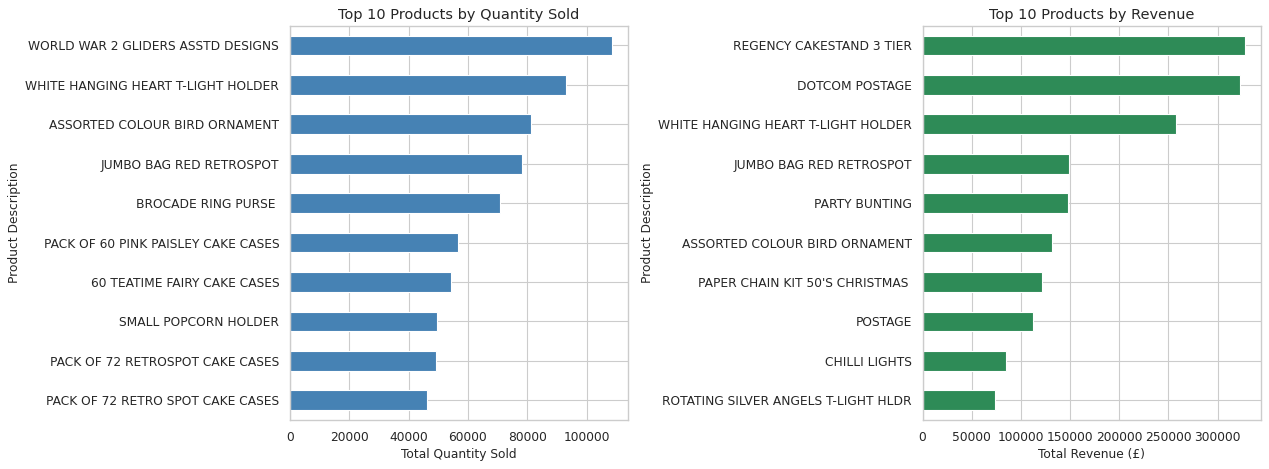

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_quantity.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Products by Quantity Sold', fontsize=13)
axes[0].set_xlabel('Total Quantity Sold', fontsize=11)
axes[0].set_ylabel('Product Description', fontsize=11)

top_revenue.sort_values().plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Top 10 Products by Revenue', fontsize=13)
axes[1].set_xlabel('Total Revenue (£)', fontsize=11)
axes[1].set_ylabel('Product Description', fontsize=11)

plt.tight_layout()
plt.show()

## 5. Sales Performance by Country

In [ ]:
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

print(" Sales Performance by Country (Top 10 by Revenue) ")
print(country_sales.head(10))

 Sales Performance by Country (Top 10 by Revenue) CountryUnited Kingdom    1.638258e+07EIRE              6.155196e+05Netherlands       5.485249e+05Germany           4.179886e+05France            3.281918e+05Australia         1.671291e+05Switzerland       9.972876e+04Spain             9.185948e+04Sweden            8.780942e+04Denmark           6.574109e+04Name: Revenue, dtype: float64

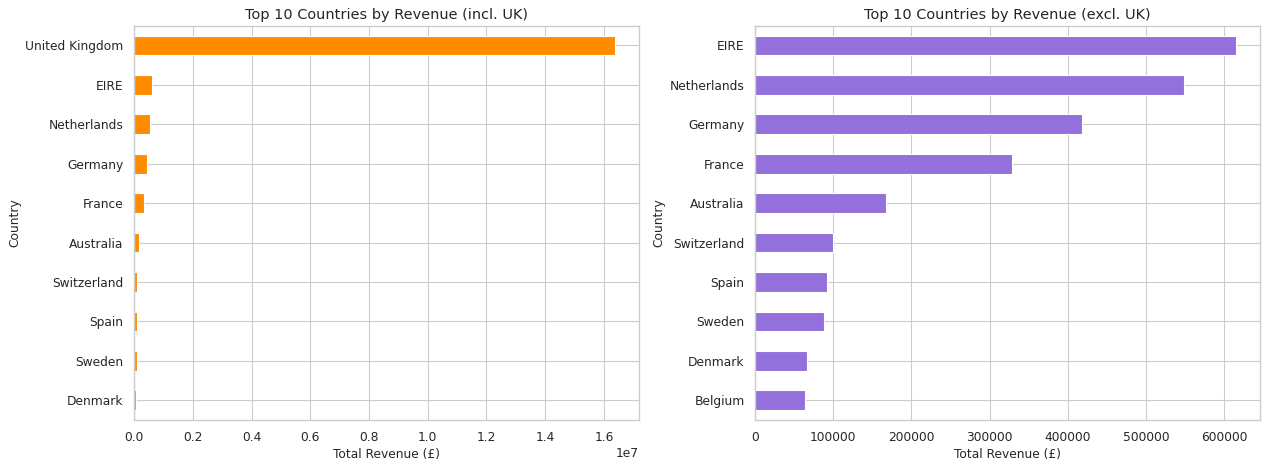

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All countries including UK
country_sales.head(10).sort_values().plot(kind='barh', ax=axes[0], color='darkorange')
axes[0].set_title('Top 10 Countries by Revenue (incl. UK)', fontsize=13)
axes[0].set_xlabel('Total Revenue (£)', fontsize=11)
axes[0].set_ylabel('Country', fontsize=11)

# Excluding UK, since it dominates and hides other trends
country_sales_no_uk = country_sales.drop('United Kingdom')
country_sales_no_uk.head(10).sort_values().plot(kind='barh', ax=axes[1], color='mediumpurple')
axes[1].set_title('Top 10 Countries by Revenue (excl. UK)', fontsize=13)
axes[1].set_xlabel('Total Revenue (£)', fontsize=11)
axes[1].set_ylabel('Country', fontsize=11)

plt.tight_layout()
plt.show()

## 6. Revenue Over Time (Monthly Trend)

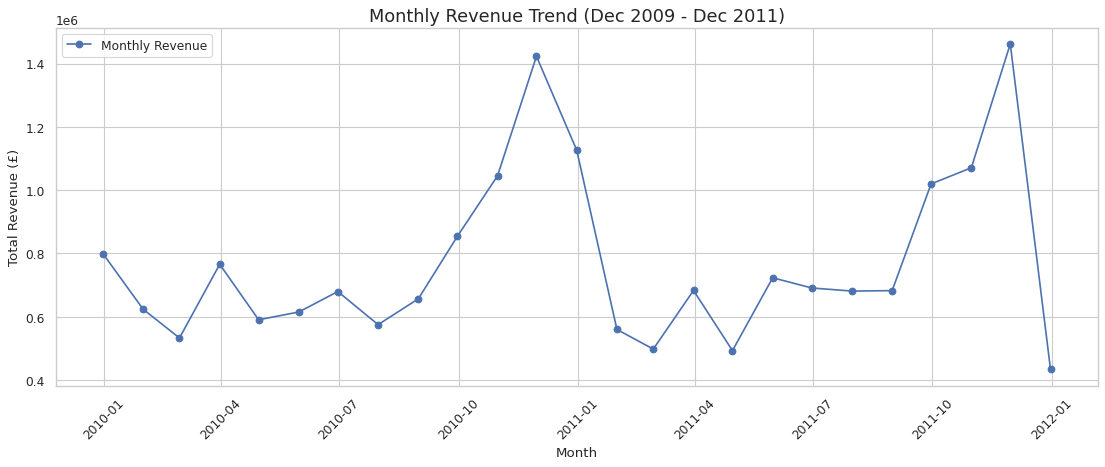

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

monthly_revenue = df.set_index('InvoiceDate').resample('ME')['Revenue'].sum()

plt.figure(figsize=(14, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', linestyle='-',
         color='b', label='Monthly Revenue')
plt.title('Monthly Revenue Trend (Dec 2009 - Dec 2011)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue (£)', fontsize=12)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Correlation Heatmap

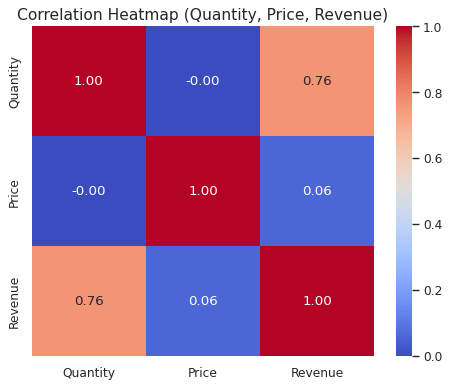

In [ ]:
plt.figure(figsize=(6, 5))
numeric_cols = df[['Quantity', 'Price', 'Revenue']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Quantity, Price, Revenue)', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Outlier Detection (Box Plots)

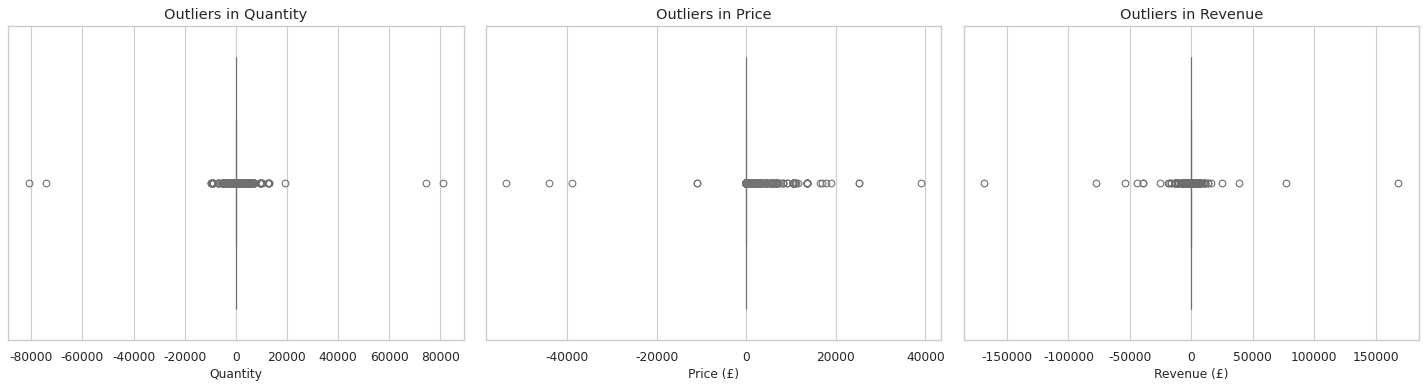

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x=df['Quantity'], ax=axes[0], color='skyblue')
axes[0].set_title('Outliers in Quantity', fontsize=13)
axes[0].set_xlabel('Quantity', fontsize=11)

sns.boxplot(x=df['Price'], ax=axes[1], color='lightgreen')
axes[1].set_title('Outliers in Price', fontsize=13)
axes[1].set_xlabel('Price (£)', fontsize=11)

sns.boxplot(x=df['Revenue'], ax=axes[2], color='salmon')
axes[2].set_title('Outliers in Revenue', fontsize=13)
axes[2].set_xlabel('Revenue (£)', fontsize=11)

plt.tight_layout()
plt.show()

**Observation:** All three numeric columns (`Quantity`, `Price`, `Revenue`) show a large number of outliers, including some extreme positive and negative values. These are consistent with bulk wholesale orders and cancelled orders. Per the task instructions, these values are reported here but **not removed**.

## 9. Business Insights

In [ ]:
total_revenue = df['Revenue'].sum()
uk_share = country_sales.iloc[0] / total_revenue * 100
n_customers = df['Customer ID'].nunique()
n_countries = df['Country'].nunique()
cancel_orders = df[df['Quantity'] < 0]['Invoice'].nunique()
total_orders = df['Invoice'].nunique()

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Unique Customers: {n_customers:,}")
print(f"Countries Served: {n_countries}")
print(f"UK Share of Revenue: {uk_share:.1f}%")
print(f"Orders containing cancellations/returns: {cancel_orders:,} out of {total_orders:,} ({cancel_orders/total_orders*100:.1f}%)")

Total Revenue: £19,287,250.57Unique Customers: 5,942Countries Served: 43UK Share of Revenue: 84.9%Orders containing cancellations/returns: 11,684 out of 53,628 (21.8%)

### Key Insights1. **UK dominates revenue overwhelmingly.** The United Kingdom alone contributes roughly 85% of total revenue, with EIRE, the Netherlands, and Germany forming a distant second tier. Any recommendation system should be trained primarily on UK behavior, with country as a strong feature for international customers.2. **Best-sellers by quantity and by revenue are different products.** Items like *WORLD WAR 2 GLIDERS ASSTD DESIGNS* and *WHITE HANGING HEART T-LIGHT HOLDER* sell in huge volumes but at low unit price, while products like *REGENCY CAKESTAND 3 TIER* and *DOTCOM POSTAGE* generate high revenue despite lower unit sales. Popularity and profitability need to be modeled separately.3. **Revenue shows clear seasonality.** Monthly revenue rises sharply in the run-up to Christmas (October–December) each year and drops off in January/February, indicating strong gift-buying seasonality that should inform inventory planning and marketing timing.4. **Data quality issues need handling before modeling.** About 23,000 rows have negative Quantity (cancellations/returns), ~243,000 rows are missing `Customer ID` (guest/unidentified transactions that can't be tied to a customer profile), and there are duplicate rows — all of which must be addressed before building a recommendation system, since missing Customer IDs in particular make those transactions unusable for personalization.5. **Quantity and Price outliers are common and likely reflect legitimate wholesale activity.** Since this appears to be a B2B-leaning retailer (bulk orders of party/gift items), extreme values in the box plots are likely genuine wholesale purchases rather than pure data errors — they should be investigated, not blindly capped or removed.6. **Revenue is only weakly correlated with either Quantity or Price alone.** The correlation heatmap shows Revenue is driven by the *combination* of Quantity and Price rather than either variable individually, which is expected but confirms that univariate pricing rules won't capture revenue behavior well.7. **A relatively small customer base drives all transactions.** With under 6,000 unique customers generating over a million transaction line items, customer-level purchase history is rich enough to support collaborative-filtering-based recommendations.